# CADF on Crypto Pairs

This notebook applies Chan's CADF workflow to shared crypto close-price fixtures.

The workflow follows the two-step Engle-Granger idea used in Section 2.2:

- estimate a hedge ratio by regressing one price series on another;
- test the regression residual with ADF;
- repeat the order because CADF is order dependent.

The notebook reads local fixtures only. Refresh fixtures with:

```bash
python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

repo_root = find_repo_root()
fixture_path = repo_root / "fixtures/crypto/crypto_daily_close.csv"

close = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close = close.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbols = ["BTCUSDT", "ETHUSDT"]
missing = [symbol for symbol in symbols if symbol not in close]
if missing:
    raise ValueError(f"Fixture is missing required symbols: {missing}")

pair_prices = close[symbols].dropna()
log_pair = np.log(pair_prices)

log_pair.tail()


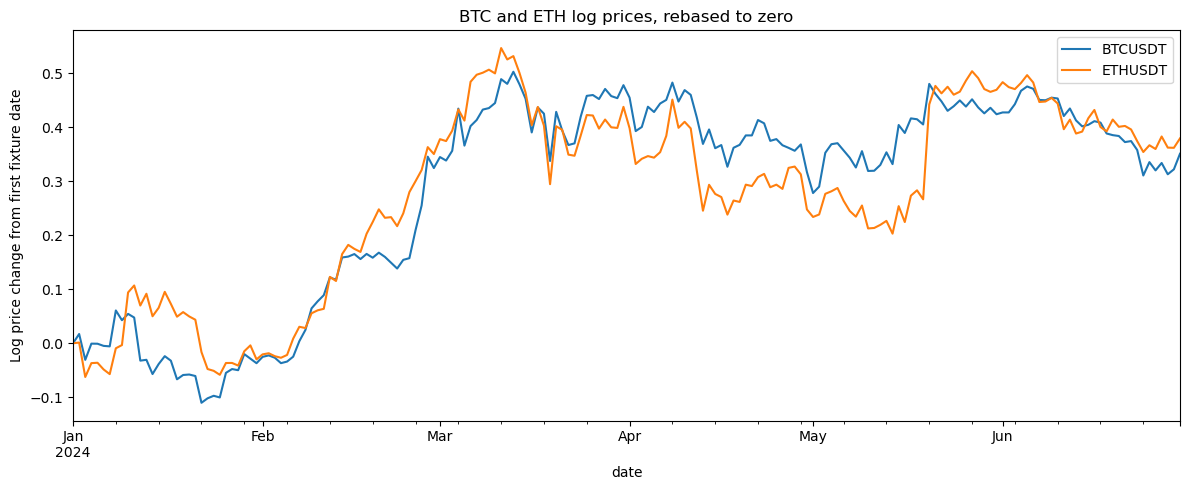

In [5]:
normalized = log_pair - log_pair.iloc[0]
normalized.plot(figsize=(12, 5), title="BTC and ETH log prices, rebased to zero")
plt.ylabel("Log price change from first fixture date")
plt.tight_layout();

In [6]:
def estimate_pair_residual(y: pd.Series, x: pd.Series) -> tuple[pd.Series, pd.Series]:
    aligned = pd.concat({"y": y, "x": x}, axis=1).dropna()
    design = np.column_stack([aligned["x"].to_numpy(), np.ones(len(aligned))])
    hedge_ratio, intercept = np.linalg.lstsq(design, aligned["y"].to_numpy(), rcond=None)[0]
    residual = aligned["y"] - hedge_ratio * aligned["x"] - intercept
    summary = pd.Series(
        {
            "dependent": y.name,
            "independent": x.name,
            "hedge_ratio": hedge_ratio,
            "intercept": intercept,
            "observations": len(aligned),
        }
    )
    return summary, residual


def run_cadf(y: pd.Series, x: pd.Series) -> tuple[pd.Series, pd.Series]:
    regression_summary, residual = estimate_pair_residual(y, x)
    stat, pvalue, usedlag, nobs, critical_values, icbest = adfuller(
        residual,
        regression="c",
        autolag="AIC",
    )
    test_summary = pd.Series(
        {
            **regression_summary.to_dict(),
            "cadf_stat": stat,
            "p_value": pvalue,
            "used_lag": usedlag,
            "n_obs_adf": nobs,
            "crit_1pct": critical_values["1%"],
            "crit_5pct": critical_values["5%"],
            "crit_10pct": critical_values["10%"],
            "reject_5pct": pvalue < 0.05,
        }
    )
    return test_summary, residual

In [7]:
forward_summary, forward_residual = run_cadf(log_pair["ETHUSDT"], log_pair["BTCUSDT"])
reverse_summary, reverse_residual = run_cadf(log_pair["BTCUSDT"], log_pair["ETHUSDT"])

cadf_results = pd.DataFrame([forward_summary, reverse_summary])
cadf_results[[
    "dependent",
    "independent",
    "hedge_ratio",
    "cadf_stat",
    "p_value",
    "crit_5pct",
    "reject_5pct",
]]

,dependent,independent,hedge_ratio,cadf_stat,p_value,crit_5pct,reject_5pct
0,ETHUSDT,BTCUSDT,0.866365,-3.097883,0.026710,-2.878106,True
1,BTCUSDT,ETHUSDT,1.014533,-2.681367,0.077318,-2.878106,False


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cadf_plot = cadf_results.assign(order=cadf_results["dependent"] + " on " + cadf_results["independent"]).set_index("order")
cadf_plot["cadf_stat"].plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].axhline(cadf_plot["crit_5pct"].iloc[0], color="tab:orange", linestyle="--", linewidth=1.5, label="5% critical value")
axes[0].set_title("CADF statistic depends on regression order")
axes[0].set_ylabel("ADF statistic on residual")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

cadf_plot["p_value"].plot(kind="bar", ax=axes[1], color=np.where(cadf_plot["reject_5pct"], "tab:green", "tab:red"))
axes[1].axhline(0.05, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual ADF p-values")
axes[1].set_ylabel("p-value")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout();


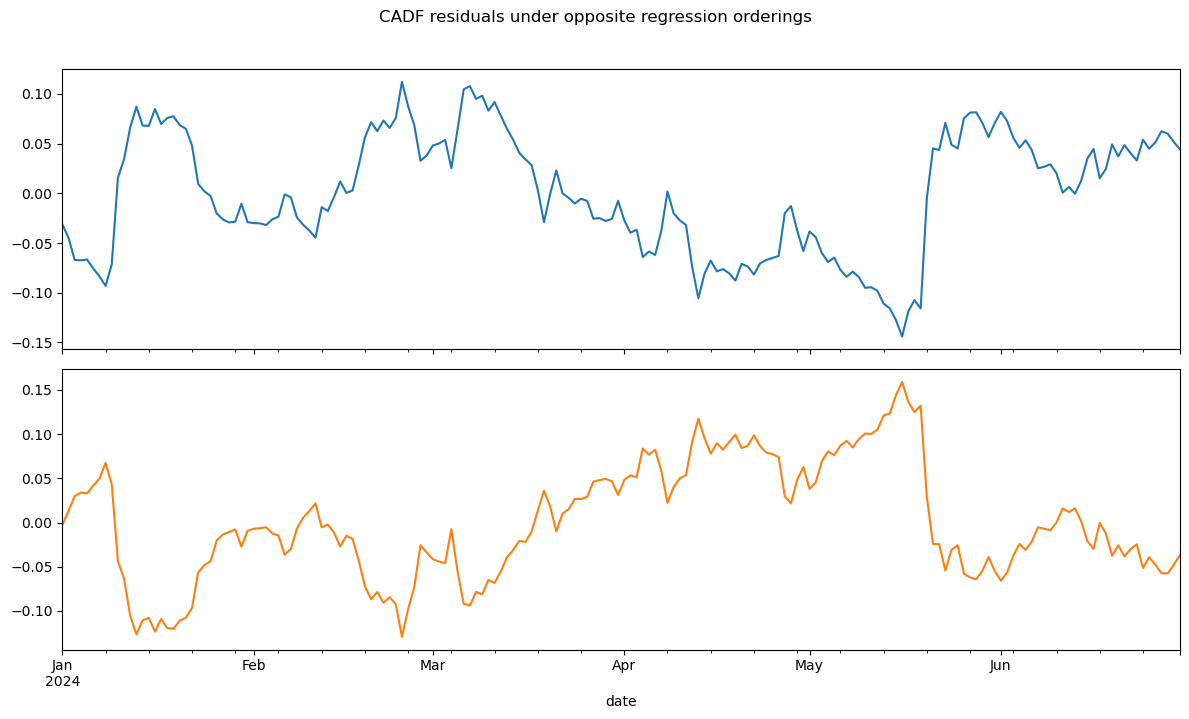

In [8]:
residuals = pd.concat(
    {
        "ETH residual after hedging BTC": forward_residual,
        "BTC residual after hedging ETH": reverse_residual,
    },
    axis=1,
)

residuals.plot(subplots=True, figsize=(12, 7), layout=(2, 1), legend=False)
plt.suptitle("CADF residuals under opposite regression orderings", y=1.02)
plt.tight_layout();

In [ ]:
zscore_residuals = (residuals - residuals.mean()) / residuals.std()

fig, ax = plt.subplots(figsize=(12, 5))
zscore_residuals.plot(ax=ax, linewidth=2)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="tab:red", linestyle="--", linewidth=1)
ax.axhline(-2, color="tab:red", linestyle="--", linewidth=1)
ax.set_title("Standardized CADF residuals show tradable spread excursions")
ax.set_ylabel("residual z-score")
plt.tight_layout();


In [9]:
best = cadf_results.sort_values("cadf_stat").iloc[0]
pd.Series(
    {
        "best_dependent": best["dependent"],
        "best_independent": best["independent"],
        "best_hedge_ratio": best["hedge_ratio"],
        "most_negative_cadf_stat": best["cadf_stat"],
        "reject_5pct": best["reject_5pct"],
    }
)

best_dependent              ETHUSDT
best_independent            BTCUSDT
best_hedge_ratio           0.866365
most_negative_cadf_stat   -3.097883
reject_5pct                    True
dtype: object

## Interpretation

The CADF result is attached to a specific regression ordering. If the two rows disagree, that is not a bug; it is the order-dependence Chan warns about. In practice, CADF users test both directions and use the ordering with the most negative test statistic if the result is statistically convincing.